<a id="sec-title"></a>

# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** [Sijie Yang](https://sijie-yang.com), [Zdravko Trivic](https://cde.nus.edu.sg/arch/staffs/zdravko-trivic-dr/), [Yihan Zhu](https://ual.sg/author/yihan-zhu/), [Mahmoud Abdelrahman](https://ual.sg/author/mahmoud-abdelrahman/), [Filip Biljecki](https://filipbiljecki.com)*

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

**All notebooks in this project (code series):**

- <a href="code_0_social_media_post_embedding.ipynb" target="_blank" rel="noopener noreferrer">code_0 — social media post embedding</a>
- <a href="code_1_social_activity_data.ipynb" target="_blank" rel="noopener noreferrer">code_1 — social activity data</a>
- <a href="code_2_geospatial_data.ipynb" target="_blank" rel="noopener noreferrer">code_2 — geospatial data</a>
- <a href="code_3_uci_social_activity_field.ipynb" target="_blank" rel="noopener noreferrer">code_3 — UCI social activity field</a>
- <a href="code_4_uci_causal_forest.ipynb" target="_blank" rel="noopener noreferrer">code_4 — UCI causal forest</a>
- <a href="code_5_uci_resident_expert_survey.ipynb" target="_blank" rel="noopener noreferrer">code_5 — resident & expert survey for UCI modelling</a>
- <a href="code_6_uci_modelling.ipynb" target="_blank" rel="noopener noreferrer">code_6 — UCI modelling</a>
- <a href="code_7_uci_optimisation_puci.ipynb" target="_blank" rel="noopener noreferrer">code_7 — UCI optimisation (pUCI & UCP)</a>
- <a href="code_8_result_analytics.ipynb" target="_blank" rel="noopener noreferrer">code_8 — result analytics</a>

**Abbreviations used in this codebase series:**  
- Comfort metrics: `UCI` (Urban Comfort Index), `UCP` (Urban Comfort Potential), `pUCI` (policy-driven Urban Comfort Index).  
- Variation metrics: `SSV` (Social-Spatial Variation), `SVI` (Social Variation Index), `SPVI` (Spatial Variation Index), `SSVI` (Socio-Spatial Variation Index).  
- Geospatial dimensions: `SP` (Streetscape Perception), `FC` (Functionality), `AC` (Accessibility), `CD` (Contact Density).
- Model and dimensions: `HGWR` (Hierarchical Geographically Weighted Regression), `CATE` (Conditional Average Treatment Effect).


<a id="sec-overview"></a>

## Data: Social Media Post Embedding Processing

This notebook covers (1) post-level **image embedding** ablation, clustering, and grid mapping; (2) post-level **caption comfort** scoring with Sentence Transformer; (3) merging activity × comfort fields and result maps.

Unless stated otherwise, all paths use `data_post_embedding/` (`P = Path('data_post_embedding')` in code cells).

**Inputs (shared):**
- Image embeddings: `dataset_post_siglip2_*.npy`, `dataset_post_resnet_features.npy`, `dataset_post_vit_features.npy`
- Grid alignment: `dataset_post_embedding_grid_id.npy`
- Caption embeddings: `dataset_post_st_caption_features.npy`, `dataset_post_caption_has_text.npy`
- Grid coordinates: `data_grid_point_coordinates.csv`

**Outputs (pipeline):**
- Clustering: `code_0_embedding_index_grid_cluster.csv`, `code_0_cluster_activity_config.json` (author labels)
- Activity intensity: `data_social_activity.gpkg`, updated `data_grid_point_coordinates.csv`
- Caption comfort: `dataset_post_comfort_*.npy`, `caption_analytics_results.csv`
- Result maps: `social_activity_comfort_*` in GPKG; figures under `figure/`

**Terminology (paper ↔ code):**
- **Activity intensity** → grid columns `eating`, `nature`, `community`, `walking`, `sightseeing` (category post counts; SI Fig.~activity intensity)
- **Activity support** (main text) $=$ activity intensity $=$ post count
- **Experience quality** → `avg_comfort_score`, `avg_comfort_{activity}` (grid mean of post-level `comfort_score`)
- **Social activity comfort** → `social_activity_comfort_{activity}` (= activity intensity × category experience quality; paper: activity support × experience quality)
- Post-level: `comfort_raw_score` = paper `text_comfort`; `comfort_score` = min–max normalised (used for all downstream aggregation)

**Section list:**

- [Title & license](#sec-title)
- [1. Ablation for different post representations](#sec-1-ablation)
- [2. K-means clustering over ResNet representation](#sec-2-kmeans)
  - [2.0 Data initialization](#sec-2-0-init)
  - [2.1 Multi-metric k-sweep](#sec-2-1-k-sweep)
  - [2.2 Composite score, plots, and ranking](#sec-2-2-composite)
  - [2.3 Production clustering, t-SNE, and export](#sec-2-3-production)
- [3. Visualisation based on categorisation results](#sec-3-viz)
  - [3.1 Setup and load grid points](#sec-3-1-setup)
  - [3.2 Aggregate activity counts per grid](#sec-3-2-aggregate)
  - [3.3 Export GPKG and grid CSV](#sec-3-3-export)
  - [3.4 Activity intensity maps](#sec-3-4-maps)
- [4. Caption analytics for comfort level evaluation](#sec-4-caption)
  - [4.1 Comfort scores from caption embeddings](#sec-4-1-comfort)
  - [4.2 Integrate comfort with activity types](#sec-4-2-integrate)
  - [4.3 Score summary and visualisation](#sec-4-3-summary)
  - [4.4 Merge comfort into grid and GPKG](#sec-4-4-merge)
- [5. Result visualisation](#sec-5-result-viz)
  - [5.1 Maps (3 panels per activity)](#sec-5-1-maps)


<a id="sec-1-ablation"></a>

## 1. Ablation for different post representations

Compare **SigLIP2** (image / fusion variants), **ResNet-50**, and **ViT-B/16** on the same aligned post rows. PCA retains ~85% variance per variant; **KMeans** ($k=8$, five seeds) yields silhouette, Davies–Bouldin, Calinski–Harabasz, and inertia. **ResNet-50** is the default downstream embedding.

| Variant key | Encoder | Dim | Source |
| --- | --- | --- | --- |
| `siglip2_image` | SigLIP2 image tower, L2 | 768 | `dataset_post_siglip2_image_only_features.npy` |
| `siglip2_fusion_equal` | SigLIP2 equal fusion | 768 | `dataset_post_siglip2_equal_features.npy` |
| `siglip2_fusion_gated` | SigLIP2 gated fusion | 768 | `dataset_post_siglip2_gated_features.npy` |
| `resnet` | ResNet-50 pool | 2048 | `dataset_post_resnet_features.npy` |
| `vit` | ViT-B/16 (ImageNet) | 768 | `dataset_post_vit_features.npy` |

**Inputs:**
- Embedding `.npy` files listed above
- `dataset_post_embedding_grid_id.npy`

**Outputs:**
- In-memory `comparison_df` (variant ranking table)
- `features`, `features_pca` set to PCA-reduced **ResNet-50** (change one line to switch winner)

**Subsections:**
- Load embeddings + PCA — next cell
- Multi-metric ablation table — cell after


In [1]:
# Load embeddings for ablation (SigLIP2 image/fusions + ResNet + ViT)
# Per-row grid id (same length as features) — aligns each embedding with `id` in data_grid_point_coordinates.csv
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA

POST_EMBED_DIR = Path('data_post_embedding')
POST_EMBED_DIR.mkdir(parents=True, exist_ok=True)
P = POST_EMBED_DIR

GRID_NPY = P / 'dataset_post_embedding_grid_id.npy'

features_siglip2_image = np.load(P / 'dataset_post_siglip2_image_only_features.npy')
features_siglip2_fusion_equal = np.load(P / 'dataset_post_siglip2_equal_features.npy')
features_siglip2_fusion_gated = np.load(P / 'dataset_post_siglip2_gated_features.npy')
features_resnet = np.load(P / 'dataset_post_resnet_features.npy')
features_vit = np.load(P / 'dataset_post_vit_features.npy')

n_align = min(
    len(features_siglip2_image),
    len(features_siglip2_fusion_equal),
    len(features_siglip2_fusion_gated),
    len(features_resnet),
    len(features_vit),
)

if GRID_NPY.exists():
    embedding_grid_id = np.load(GRID_NPY).astype(np.int64).reshape(-1)
    if len(embedding_grid_id) < n_align:
        raise ValueError(f'{GRID_NPY} length {len(embedding_grid_id)} < feature rows {n_align}')
    embedding_grid_id = embedding_grid_id[:n_align]
else:
    raise FileNotFoundError(
        f'Missing {GRID_NPY} (length must match embeddings). '
        f'Run the next OPTIONAL cell once if you still have dataset_post_siglip2_image_paths.npy '
        f'to build grid ids from paths like .../photos_2/<grid_id>/...; otherwise create the array yourself.'
    )

features_siglip2_image = features_siglip2_image[:n_align].astype(np.float32)
features_siglip2_fusion_equal = features_siglip2_fusion_equal[:n_align].astype(np.float32)
features_siglip2_fusion_gated = features_siglip2_fusion_gated[:n_align].astype(np.float32)
features_resnet = features_resnet[:n_align].astype(np.float32)
features_vit = features_vit[:n_align].astype(np.float32)

# variance_target: float in (0,1) = keep components until cumulative variance >= target
def _pca_transform(X, name, random_state=42, variance_target=0.85, max_components=None):
    n_rank = max(1, X.shape[0] - 1)
    n_feat = X.shape[1]
    if max_components is not None:
        n_comp = min(int(max_components), n_rank, n_feat)
        pca = PCA(n_components=n_comp, random_state=random_state)
    else:
        pca = PCA(n_components=variance_target, random_state=random_state)
    Z = pca.fit_transform(X.astype(np.float64)).astype(np.float32)
    print(f'  {name}: {X.shape[1]}D -> {Z.shape[1]}D, var explained={pca.explained_variance_ratio_.sum():.4f}')
    return Z

print('Aligned rows:', n_align)
print('Grid id array:', embedding_grid_id.shape, 'valid (>=0):', int(np.sum(embedding_grid_id >= 0)))
print('PCA per variant (retain 85% variance by default; set max_components=512 to cap dims):')
features_siglip2_image = _pca_transform(features_siglip2_image, 'siglip2_image')
features_siglip2_fusion_equal = _pca_transform(features_siglip2_fusion_equal, 'siglip2_fusion_equal')
features_siglip2_fusion_gated = _pca_transform(features_siglip2_fusion_gated, 'siglip2_fusion_gated')
features_resnet = _pca_transform(features_resnet, 'resnet')
features_vit = _pca_transform(features_vit, 'vit')

# Default embedding for downstream (change if another variant wins ablation)
features = features_resnet
features_pca = features


Aligned rows: 44228
Grid id array: (44228,) valid (>=0): 44228
PCA per variant (retain 85% variance by default; set max_components=512 to cap dims):
  siglip2_image: 768D -> 253D, var explained=0.8502
  siglip2_fusion_equal: 768D -> 289D, var explained=0.8505
  siglip2_fusion_gated: 768D -> 254D, var explained=0.8503
  resnet: 2048D -> 156D, var explained=0.8502
  vit: 768D -> 370D, var explained=0.8506


In [3]:
# Compare all rows in the Ablation table with multi-metric + multi-seed stats
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
import pandas as pd
from tqdm import tqdm
import numpy as np

n_clusters_eval = 8
rng = np.random.RandomState(42)
seeds_eval = [0, 1, 2, 3, 4]

variants = {
    'siglip2_image': features_siglip2_image,
    'siglip2_fusion_equal': features_siglip2_fusion_equal,
    'siglip2_fusion_gated': features_siglip2_fusion_gated,
    'resnet': features_resnet,
    'vit': features_vit,
}

n_total = min(len(emb) for emb in variants.values())
sample_n = min(n_total, 10000)
idx = rng.choice(n_total, size=sample_n, replace=False) if n_total > sample_n else np.arange(n_total)
print(f'Ablation sample: {sample_n} / {n_total} rows (aligned across variants)')
print(f'Metrics over {len(seeds_eval)} seeds: {seeds_eval}')

rows = []
for name, emb in tqdm(variants.items(), desc='Ablation variants'):
    emb_s = emb[idx]

    sil_list, db_list, ch_list, inertia_list = [], [], [], []
    for sd in seeds_eval:
        km = KMeans(n_clusters=n_clusters_eval, n_init=10, random_state=sd)
        labels = km.fit_predict(emb_s)

        sil = silhouette_score(
            emb_s,
            labels,
            sample_size=min(5000, len(emb_s)) if len(emb_s) > 5000 else None,
            random_state=sd,
        )
        db = davies_bouldin_score(emb_s, labels)
        ch = calinski_harabasz_score(emb_s, labels)

        sil_list.append(float(sil))
        db_list.append(float(db))
        ch_list.append(float(ch))
        inertia_list.append(float(km.inertia_))

    rows.append({
        'variant': name,
        'silhouette_mean': float(np.mean(sil_list)),
        'silhouette_std': float(np.std(sil_list)),
        'db_mean': float(np.mean(db_list)),
        'db_std': float(np.std(db_list)),
        'ch_mean': float(np.mean(ch_list)),
        'ch_std': float(np.std(ch_list)),
        'inertia_mean': float(np.mean(inertia_list)),
        'inertia_std': float(np.std(inertia_list)),
    })

comparison_df = pd.DataFrame(rows).sort_values('silhouette_mean', ascending=False)
print(comparison_df)
print('Ablation complete.')


Ablation sample: 10000 / 44228 rows (aligned across variants)
Metrics over 5 seeds: [0, 1, 2, 3, 4]


Ablation variants: 100%|██████████| 5/5 [00:27<00:00,  5.43s/it]

                variant  silhouette_mean  silhouette_std   db_mean    db_std  \
3                resnet         0.054830        0.000732  3.623524  0.001202   
0         siglip2_image         0.044753        0.001734  3.951533  0.039122   
2  siglip2_fusion_gated         0.044158        0.002202  3.963393  0.019093   
4                   vit         0.028705        0.000653  4.908750  0.009976   
1  siglip2_fusion_equal         0.026676        0.001321  4.280320  0.092392   

      ch_mean    ch_std  inertia_mean  inertia_std  
3  321.576398  0.003934  2.422685e+06     5.299528  
0  258.678986  1.409727  3.483000e+03     2.915478  
2  259.933472  0.187201  3.451621e+03     0.382763  
4  161.844955  0.010975  2.694607e+06    18.763395  
1  225.793216  0.676371  2.473688e+03     1.012346  
Ablation complete.


<a id="sec-2-kmeans"></a>

## 2. K-means clustering over ResNet representation

Production clustering on PCA-reduced **ResNet-50** features (`features_pca`): sweep candidate $k$, rank with a composite score, fit **KMeans** on the full corpus, and export per-post cluster ids.

**Inputs:**
- `features_pca` from §1 or §2.0
- `dataset_post_embedding_grid_id.npy` (for export in §2.3)

**Outputs:**
- `k_eval_df` (k-sweep metrics; §2.1–§2.2)
- `code_0_embedding_index_grid_cluster.csv` (§2.3)
- Figures: `figure/code_0_k_selection.png`, `figure/code_0_tsne_clusters.png`

**Subsections:**
- [2.0 Data initialization](#sec-2-0-init) — run first if skipping §1
- [2.1 Multi-metric k-sweep](#sec-2-1-k-sweep) — expensive; run once
- [2.2 Composite score, plots, and ranking](#sec-2-2-composite) — cheap; re-run to tune weights
- [2.3 Production clustering, t-SNE, and export](#sec-2-3-production) — fit $k=8$, visualise, write CSV


<a id="sec-2-0-init"></a>

### 2.0 Data initialization

Load **ResNet-50** embeddings and grid ids; apply PCA (85% variance retained). Sets `features_pca` for §2.1–§2.3. Skip §1 when you only need clustering (not the embedding ablation).


In [1]:
# §2.0 — ResNet-only init (skip §1 ablation)
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA

POST_EMBED_DIR = Path('data_post_embedding')
POST_EMBED_DIR.mkdir(parents=True, exist_ok=True)
P = POST_EMBED_DIR

features_resnet_raw = np.load(P / 'dataset_post_resnet_features.npy')
embedding_grid_id = np.load(P / 'dataset_post_embedding_grid_id.npy').astype(np.int64).reshape(-1)

n_align = min(len(features_resnet_raw), len(embedding_grid_id))
if len(embedding_grid_id) < len(features_resnet_raw):
    raise ValueError(
        f'dataset_post_embedding_grid_id.npy length {len(embedding_grid_id)} '
        f'< feature rows {len(features_resnet_raw)}'
    )

features_resnet_raw = features_resnet_raw[:n_align].astype(np.float32)
embedding_grid_id = embedding_grid_id[:n_align]

pca = PCA(n_components=0.85, random_state=42)
features_pca = pca.fit_transform(features_resnet_raw.astype(np.float64)).astype(np.float32)
features = features_pca  # alias used by t-SNE cell

print('Aligned rows:', n_align)
print('Grid id array:', embedding_grid_id.shape, 'valid (>=0):', int(np.sum(embedding_grid_id >= 0)))
print(
    f'ResNet PCA: {features_resnet_raw.shape[1]}D -> {features_pca.shape[1]}D, '
    f'var explained={pca.explained_variance_ratio_.sum():.4f}'
)
print('Ready for §2.1 k-sweep and §2.3 production KMeans.')


Aligned rows: 44228
Grid id array: (44228,) valid (>=0): 44228
ResNet PCA: 2048D -> 156D, var explained=0.8502
Ready for §2.1 k-sweep and §2.3 production KMeans.


<a id="sec-2-1-k-sweep"></a>

### 2.1 Multi-metric k-sweep

Run **KMeans** over $k \in \{2, \ldots, 25\}$ with five seeds each. Record silhouette, Davies–Bouldin, seed-stability ARI, cluster-size CV, and inertia. Outputs `k_eval_df` (raw metrics table).


In [33]:
# compute k-sweep metrics table (EXPENSIVE: KMeans over k range x seeds)
# Run this once; tune the composite score in the next (cheap) cell without re-running KMeans.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from tqdm import tqdm
import numpy as np
import pandas as pd

# features_pca: PCA-reduced in load cell (same as default `features`)
X = np.asarray(features_pca)

k_min, k_max = 2, 26
k_range = list(range(k_min, k_max))
seeds = [0, 1, 2, 3, 4]
sample_size = min(10000, len(X)) if len(X) > 10000 else None

rows = []

for k in tqdm(k_range, desc='KMeans multi-metric k sweep'):
    inertia_list, sil_list, ch_list, db_list = [], [], [], []
    labels_list = []
    size_cv_list, min_frac_list = [], []

    for s in seeds:
        km = KMeans(n_clusters=k, random_state=s, n_init=10)
        labels = km.fit_predict(X)
        cnt = np.bincount(labels, minlength=k).astype(float)

        inertia_list.append(km.inertia_)
        sil_list.append(silhouette_score(X, labels, sample_size=sample_size, random_state=s))
        ch_list.append(calinski_harabasz_score(X, labels))
        db_list.append(davies_bouldin_score(X, labels))
        labels_list.append(labels)
        size_cv_list.append(float(cnt.std() / (cnt.mean() + 1e-12)))
        min_frac_list.append(float(cnt.min() / cnt.sum()))

    ari_vals = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            ari_vals.append(adjusted_rand_score(labels_list[i], labels_list[j]))

    rows.append({
        'k': k,
        'inertia_mean': float(np.mean(inertia_list)),
        'inertia_std': float(np.std(inertia_list)),
        'silhouette_mean': float(np.mean(sil_list)),
        'silhouette_std': float(np.std(sil_list)),
        'calinski_harabasz_mean': float(np.mean(ch_list)),
        'davies_bouldin_mean': float(np.mean(db_list)),
        'seed_stability_ari_mean': float(np.mean(ari_vals)),
        'size_cv_mean': float(np.mean(size_cv_list)),
        'min_cluster_frac_mean': float(np.mean(min_frac_list)),
    })

k_eval_df = pd.DataFrame(rows)

try:
    from IPython.display import display
except Exception:
    display = print

print('k_eval_df (raw metrics) is ready. Run the composite-score cell next.')
display(k_eval_df.round(4))


KMeans multi-metric k sweep: 100%|██████████| 24/24 [05:58<00:00, 14.93s/it]

k_eval_df (raw metrics) is ready. Run the composite-score cell next.


,k,inertia_mean,inertia_std,silhouette_mean,silhouette_std,calinski_harabasz_mean,davies_bouldin_mean,seed_stability_ari_mean,size_cv_mean,min_cluster_frac_mean
0,2,12354364.8,2.7129,0.0766,0.0011,2793.6206,2.8883,0.9989,0.6551,0.1725
1,3,11784333.4,1.3565,0.0628,0.0004,2533.9473,3.6434,0.9996,0.4416,0.1476
2,4,11419716.0,5.3292,0.0583,0.0007,2213.8757,3.5612,0.9901,0.3559,0.1446
3,5,11197772.6,1.3565,0.0571,0.0005,1912.4049,3.8734,0.9949,0.2532,0.1426
4,6,11008504.2,7.2774,0.0567,0.0005,1708.2546,3.7407,0.9832,0.1787,0.1219
5,7,10842022.4,1.4967,0.0562,0.0005,1558.5426,3.7073,0.9906,0.1715,0.0950
6,8,10717049.2,1.6000,0.0555,0.0006,1425.1073,3.6537,0.9896,0.2035,0.0866
7,9,10607755.4,3.2000,0.0501,0.0005,1316.7369,3.6176,0.9922,0.2039,0.0740
8,10,10521823.4,12.7530,0.0516,0.0005,1220.0920,3.5681,0.9836,0.2758,0.0496
9,11,10443203.4,906.4157,0.0471,0.0011,1139.6125,3.6883,0.7790,0.2500,0.0500


In [84]:
# compute composite score (CHEAP: operates on k_eval_df, no KMeans re-run)
import numpy as np

# Exclude k=2 entirely: too coarse to be a meaningful activity partition. Dropping
# it here means it is not considered anywhere downstream (elbow chord endpoint,
# z-scores, composite ranking, plots). Re-run the KMeans cell to restore k=2.
k_eval_df = k_eval_df[k_eval_df['k'] >= 3].reset_index(drop=True)

# Elbow strength per k: normalized perpendicular distance from the inertia curve
# to the chord joining its two endpoints. It is ~0 at both extremes (smallest and
# largest k) and peaks at the elbow, so adding it pushes the selected k away from
# the trivially-small values that silhouette/DB tend to favour.
_k = k_eval_df['k'].to_numpy(float)
_sse = k_eval_df['inertia_mean'].to_numpy(float)
_kn = (_k - _k.min()) / (_k.max() - _k.min() + 1e-12)
_sn = (_sse - _sse.min()) / (_sse.max() - _sse.min() + 1e-12)
_p1, _p2 = np.array([_kn[0], _sn[0]]), np.array([_kn[-1], _sn[-1]])
_line = (_p2 - _p1) / (np.linalg.norm(_p2 - _p1) + 1e-12)
_dist = []
for _x, _y in zip(_kn, _sn):
    _v = np.array([_x, _y]) - _p1
    _dist.append(float(np.linalg.norm(_v - _v.dot(_line) * _line)))
k_eval_df['elbow_strength'] = _dist
elbow_k = int(k_eval_df.loc[k_eval_df['elbow_strength'].idxmax(), 'k'])

# Composite score: separation (silhouette, Davies-Bouldin) + seed stability +
# elbow strength (keeps k from collapsing to the smallest value) + light size penalty.
COMPOSITE_COLS = [
    'silhouette_mean',
    'seed_stability_ari_mean',
    'davies_bouldin_mean',
    'size_cv_mean',
    'elbow_strength',
]
COMPOSITE_WEIGHTS = {
    'silhouette_mean': 0.3,
    'seed_stability_ari_mean': 0.1,
    'davies_bouldin_mean': 0.2,
    'size_cv_mean': 0.1,
    'elbow_strength': 0.3,
}

# z-score each metric over the full k sweep (no feasibility restrictions)
for c in COMPOSITE_COLS:
    mu, sd = k_eval_df[c].mean(), k_eval_df[c].std() + 1e-12
    k_eval_df[c + '_z'] = (k_eval_df[c] - mu) / sd

k_eval_df['composite_score'] = (
    + COMPOSITE_WEIGHTS['silhouette_mean'] * k_eval_df['silhouette_mean_z']
    + COMPOSITE_WEIGHTS['seed_stability_ari_mean'] * k_eval_df['seed_stability_ari_mean_z']
    - COMPOSITE_WEIGHTS['davies_bouldin_mean'] * k_eval_df['davies_bouldin_mean_z']
    - COMPOSITE_WEIGHTS['size_cv_mean'] * k_eval_df['size_cv_mean_z']
    + COMPOSITE_WEIGHTS['elbow_strength'] * k_eval_df['elbow_strength_z']
)

selected_k = int(k_eval_df.loc[k_eval_df['composite_score'].idxmax(), 'k'])
print('k_eval_df now has composite_score; ready for plotting and ranking.')
print(f'Elbow k (max chord distance): {elbow_k}')
print(
    f'Best k by composite score '
    f'(k {int(k_eval_df["k"].min())}-{int(k_eval_df["k"].max())}): {selected_k}'
)


k_eval_df now has composite_score; ready for plotting and ranking.
Elbow k (max chord distance): 9
Best k by composite score (k 3-25): 8


<a id="sec-2-2-composite"></a>

### 2.2 Composite score, plots, and ranking

Exclude $k=2$; compute elbow strength and composite score (no KMeans re-run). Plot six diagnostic curves and print the ranked table. Adjust `COMPOSITE_WEIGHTS` and re-run this subsection only.


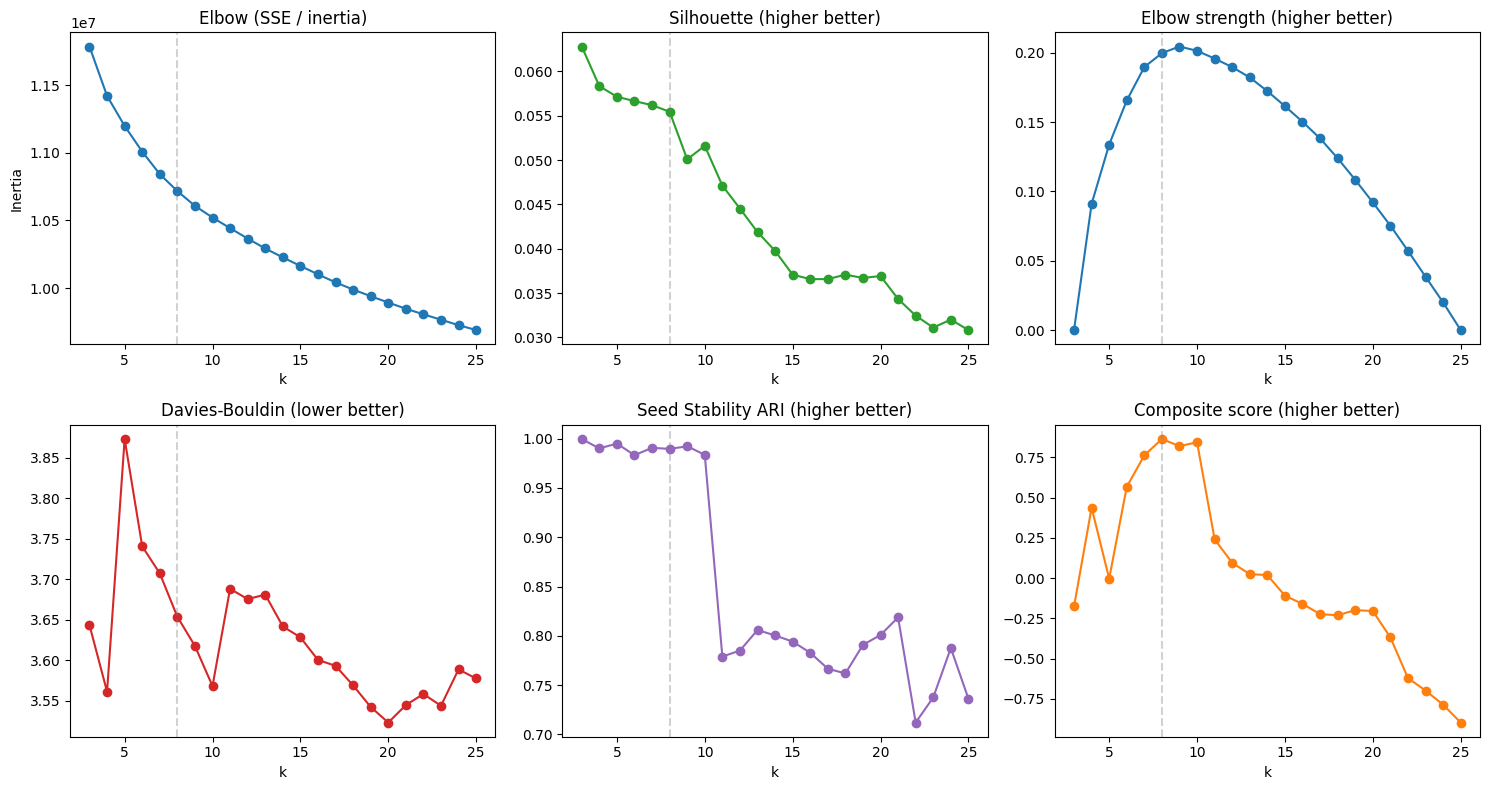

In [88]:
# plot metrics curves
import matplotlib.pyplot as plt

# display only (k>=3): k=2 is dropped from the plots, not from k_eval_df / composite
plot_df = k_eval_df[k_eval_df['k'] >= 3]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(plot_df['k'], plot_df['inertia_mean'], marker='o')
axes[0, 0].set_title('Elbow (SSE / inertia)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(plot_df['k'], plot_df['silhouette_mean'], marker='o', color='tab:green')
axes[0, 1].set_title('Silhouette (higher better)')
axes[0, 1].set_xlabel('k')

axes[0, 2].plot(plot_df['k'], plot_df['elbow_strength'], marker='o', color='tab:blue')
axes[0, 2].set_title('Elbow strength (higher better)')
axes[0, 2].set_xlabel('k')

axes[1, 0].plot(plot_df['k'], plot_df['davies_bouldin_mean'], marker='o', color='tab:red')
axes[1, 0].set_title('Davies-Bouldin (lower better)')
axes[1, 0].set_xlabel('k')

axes[1, 1].plot(plot_df['k'], plot_df['seed_stability_ari_mean'], marker='o', color='tab:purple')
axes[1, 1].set_title('Seed Stability ARI (higher better)')
axes[1, 1].set_xlabel('k')

axes[1, 2].plot(plot_df['k'], plot_df['composite_score'], marker='o', color='tab:orange')
axes[1, 2].set_title('Composite score (higher better)')
axes[1, 2].set_xlabel('k')

for ax in axes.ravel():
    ax.axvline(selected_k, linestyle='--', alpha=0.35, color='gray')

plt.tight_layout()
fig.savefig('figure/code_0_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()


In [89]:
try:
    from IPython.display import display
except Exception:
    display = print

# ranking table by composite score
show_cols = [
    'k',
    'inertia_mean', 'inertia_std',
    'silhouette_mean', 'silhouette_std',
    'calinski_harabasz_mean',
    'davies_bouldin_mean',
    'seed_stability_ari_mean',
    'size_cv_mean',
    'min_cluster_frac_mean',
    'elbow_strength',
    'composite_score',
]

print('[Composite score — full k sweep]')
print('Weights: silhouette 0.30, ARI 0.10, DB 0.20, size_cv 0.10, elbow 0.30 (z-scored over all k)')
display(
    k_eval_df[show_cols]
    .sort_values('composite_score', ascending=False)
    .round(4)
)

best_k_sil = int(k_eval_df.loc[k_eval_df['silhouette_mean'].idxmax(), 'k'])
best_k_comp = int(k_eval_df.loc[k_eval_df['composite_score'].idxmax(), 'k'])

print(f'\nBest k by silhouette: {best_k_sil}')
print(f'Best k by composite score: {best_k_comp}')

recommended_k = best_k_comp
print(f'\nSelected k for production: {recommended_k}')


[Composite score — full k sweep]
Weights: silhouette 0.30, ARI 0.10, DB 0.20, size_cv 0.10, elbow 0.30 (z-scored over all k)


,k,inertia_mean,inertia_std,silhouette_mean,silhouette_std,calinski_harabasz_mean,davies_bouldin_mean,seed_stability_ari_mean,size_cv_mean,min_cluster_frac_mean,elbow_strength,composite_score
5,8,10717049.2,1.6000,0.0555,0.0006,1425.1073,3.6537,0.9896,0.2035,0.0866,0.1998,0.8635
7,10,10521823.4,12.7530,0.0516,0.0005,1220.0920,3.5681,0.9836,0.2758,0.0496,0.2015,0.8434
6,9,10607755.4,3.2000,0.0501,0.0005,1316.7369,3.6176,0.9922,0.2039,0.0740,0.2046,0.8191
4,7,10842022.4,1.4967,0.0562,0.0005,1558.5426,3.7073,0.9906,0.1715,0.0950,0.1897,0.7623
3,6,11008504.2,7.2774,0.0567,0.0005,1708.2546,3.7407,0.9832,0.1787,0.1219,0.1657,0.5665
1,4,11419716.0,5.3292,0.0583,0.0007,2213.8757,3.5612,0.9901,0.3559,0.1446,0.0910,0.4370
8,11,10443203.4,906.4157,0.0471,0.0011,1139.6125,3.6883,0.7790,0.2500,0.0500,0.1959,0.2409
9,12,10366340.6,1042.4154,0.0445,0.0014,1073.4735,3.6755,0.7850,0.2975,0.0426,0.1897,0.0951
10,13,10293275.2,2207.9774,0.0419,0.0018,1017.1342,3.6811,0.8059,0.2770,0.0430,0.1823,0.0246
11,14,10227315.0,1252.2821,0.0398,0.0029,966.8624,3.6418,0.8004,0.2721,0.0361,0.1724,0.0192



Best k by silhouette: 3
Best k by composite score: 8

Selected k for production: 8


<a id="sec-2-3-production"></a>

### 2.3 Production clustering, t-SNE, and export

1. Fit **KMeans** with selected $k=8$ on all posts (`features_pca`).
2. Visualise clusters with t-SNE.
3. Write `code_0_embedding_index_grid_cluster.csv`.


In [90]:
# §2.3 step 1 — production KMeans on full corpus
from sklearn.cluster import KMeans

n_clusters = 8  # from §2.2 composite score (override if needed)
kmeans = KMeans(n_clusters=n_clusters, n_init=5, random_state=0).fit(features_pca)
print(f'KMeans fitted: k={n_clusters}, n={len(kmeans.labels_)}')


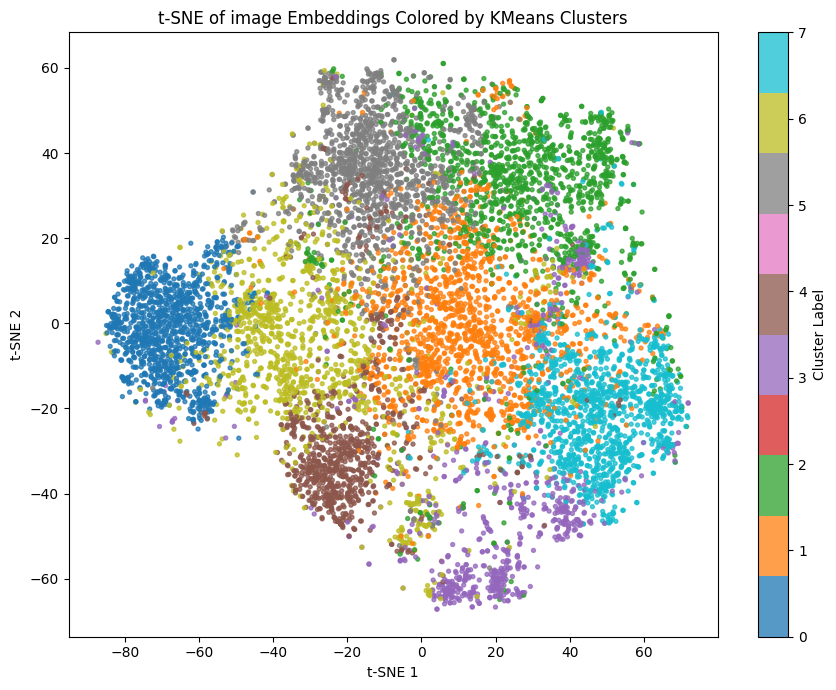

In [92]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE visualization of cluster result
n_samples = min(len(features), 10000)  # speed-up for large datasets
rng = np.random.RandomState(42)
idx = rng.choice(len(features), size=n_samples, replace=False) if len(features) > n_samples else np.arange(len(features))

features_vis = features[idx]
labels_vis = np.array(kmeans.labels_)[idx]

tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
features_2d = tsne.fit_transform(features_vis)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_vis, s=8, cmap='tab10', alpha=0.75)
plt.title('t-SNE of image Embeddings Colored by KMeans Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster Label')
plt.tight_layout()
plt.gcf().savefig('figure/code_0_tsne_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


In [93]:
# Persist: embedding row index -> grid_id + cluster (after k-means)
import numpy as np
import pandas as pd
from pathlib import Path

P = Path('data_post_embedding')
map_df = pd.DataFrame({
    'embedding_index': np.arange(len(kmeans.labels_), dtype=np.int64),
    'grid_id': embedding_grid_id,
    'cluster': kmeans.labels_.astype(np.int64),
})
out_csv = P / 'code_0_embedding_index_grid_cluster.csv'
map_df.to_csv(out_csv, index=False)
print('Saved', out_csv, map_df.shape)


Saved data_post_embedding/code_0_embedding_index_grid_cluster.csv (44228, 3)


<a id="sec-3-viz"></a>

## 3. Visualisation based on categorisation results

Aggregate post-level cluster assignments to grid-level activity intensities, export a geopackage, and map all five activity categories.

**Inputs:**
- `data_grid_point_coordinates.csv` — columns `id`, `longitude`, `latitude` (2096 Singapore grid points)
- `code_0_embedding_index_grid_cluster.csv` — columns `embedding_index`, `grid_id`, `cluster`
- `code_0_cluster_activity_config.json` — author cluster → activity mapping

**Outputs:**
- `data_social_activity.gpkg` — activity intensity columns per grid (`eating`, …)
- Updated `data_grid_point_coordinates.csv`
- `figure/code_0_activity_intensity.png`

**Subsections:**
- [3.1 Setup and load grid points](#sec-3-1-setup)
- [3.2 Aggregate activity counts per grid](#sec-3-2-aggregate)
- [3.3 Export GPKG and grid CSV](#sec-3-3-export)
- [3.4 Activity intensity maps](#sec-3-4-maps)


<a id="sec-3-1-setup"></a>

### 3.1 Setup and load grid points

Import libraries and load `data_grid_point_coordinates.csv`.


In [10]:
# Setup
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Point

P = Path('data_post_embedding')
POINTS_CSV = P / 'data_grid_point_coordinates.csv'  # must include id, longitude, latitude

df = pd.read_csv(POINTS_CSV)
print('Loaded points:', POINTS_CSV.resolve(), df.shape)


Loaded points: /Users/sijieyang/Documents/Urban-Comfort-Potential/data_post_embedding/data_grid_point_coordinates.csv (2096, 14)


<a id="sec-3-2-aggregate"></a>

### 3.2 Aggregate activity counts per grid

Join cluster assignments with activity config; count posts per grid × activity (`eating`, `nature`, `community`, `walking`, `sightseeing`).


In [11]:
# Per-grid activity counts from code_0_embedding_index_grid_cluster.csv + code_0_cluster_activity_config.json
map_csv = P / 'code_0_embedding_index_grid_cluster.csv'
if not map_csv.exists():
    raise FileNotFoundError(
        f'Missing {map_csv}. Run section 2 (KMeans) once to export it, or place the CSV under {P.resolve()}.'
    )

map_df = pd.read_csv(map_csv)
for col in ('grid_id', 'cluster'):
    if col not in map_df.columns:
        raise ValueError(f'{map_csv} must contain column {col!r}')

cfg_path = P / 'code_0_cluster_activity_config.json'
if not cfg_path.exists():
    raise FileNotFoundError(f'Missing {cfg_path}. Place code_0_cluster_activity_config.json under {P.resolve()}.')
cfg = json.loads(cfg_path.read_text(encoding='utf-8'))
drop = set(int(x) for x in cfg.get('drop_clusters', []))
raw_map = cfg.get('cluster_to_activity', {})
cluster_to_activity = {}
for k, v in raw_map.items():
    if v is None or str(v).lower() in ('null', 'none', ''):
        continue
    cluster_to_activity[int(k)] = str(v).strip().lower()

ACT = ['eating', 'nature', 'community', 'walking', 'sightseeing']
for a in cluster_to_activity.values():
    if a not in ACT:
        raise ValueError(f'Unknown activity {a!r}; use one of {ACT}')

labels = map_df['cluster'].astype(np.int64).values
gid = map_df['grid_id'].astype(np.int64).values

activity = []
for i in range(len(labels)):
    c = int(labels[i])
    if c in drop:
        activity.append(None)
        continue
    activity.append(cluster_to_activity.get(c))
emb_act = pd.DataFrame({'grid_id': gid, 'activity': activity})
emb_act = emb_act[emb_act['grid_id'] >= 0]
emb_act = emb_act[emb_act['activity'].notna()]

if emb_act.empty:
    print('Warning: no embeddings counted (check grid_id and cluster mapping).')
else:
    counts = emb_act.groupby(['grid_id', 'activity']).size().unstack(fill_value=0)
    for a in ACT:
        if a not in counts.columns:
            counts[a] = 0
    counts = counts[ACT]
    df_idx = df.set_index('id')
    for a in ACT:
        df_idx[a] = df_idx.index.map(counts[a].to_dict()).fillna(0).astype(int)
    df = df_idx.reset_index()
    print('Attached activity count columns:', ACT)


Attached activity count columns: ['eating', 'nature', 'community', 'walking', 'sightseeing']


<a id="sec-3-3-export"></a>

### 3.3 Export GPKG and grid CSV

Build a GeoDataFrame from grid coordinates and activity columns; write `data_social_activity.gpkg` and refresh `data_grid_point_coordinates.csv`.


In [12]:
# Convert DataFrame to GeoDataFrame; save both GPKG and data_grid_point_coordinates.csv
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))
output_gpkg = P / 'data_social_activity.gpkg'
gdf.to_file(output_gpkg, driver='GPKG')
df.to_csv(POINTS_CSV, index=False, encoding='utf-8-sig')
print('Saved GPKG:', output_gpkg.resolve())
print('Updated CSV:', POINTS_CSV.resolve())
gdf


Saved GPKG: /Users/sijieyang/Documents/Urban-Comfort-Potential/data_post_embedding/data_social_activity.gpkg
Updated CSV: /Users/sijieyang/Documents/Urban-Comfort-Potential/data_post_embedding/data_grid_point_coordinates.csv


/Users/sijieyang/anaconda3/lib/python3.11/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


,id,longitude,latitude,eating,nature,community,walking,sightseeing,avg_comfort_score,avg_comfort_eating,avg_comfort_nature,avg_comfort_community,avg_comfort_walking,avg_comfort_sightseeing,geometry
0,0,103.610,1.230,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (103.61 1.23)
1,1,103.610,1.235,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (103.61 1.235)
2,2,103.610,1.250,8,1,3,11,13,0.559116,0.561076,0.357431,0.468780,0.535751,0.565555,POINT (103.61 1.25)
3,3,103.610,1.260,0,0,0,5,1,0.540892,0.000000,0.000000,0.000000,0.548579,0.548223,POINT (103.61 1.26)
4,4,103.610,1.265,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (103.61 1.265)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2091,2091,104.025,1.365,0,0,1,0,0,0.643017,0.000000,0.000000,0.620974,0.000000,0.000000,POINT (104.025 1.365)
2092,2092,104.030,1.320,4,2,1,7,6,0.689083,0.776289,0.775027,0.637997,0.720309,0.614321,POINT (104.03 1.32)
2093,2093,104.030,1.350,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (104.03 1.35)
2094,2094,104.030,1.355,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (104.03 1.355)


<a id="sec-3-4-maps"></a>

### 3.4 Activity intensity maps

Plot a one-row panel of five activity intensity maps; save `figure/code_0_activity_intensity.png`.


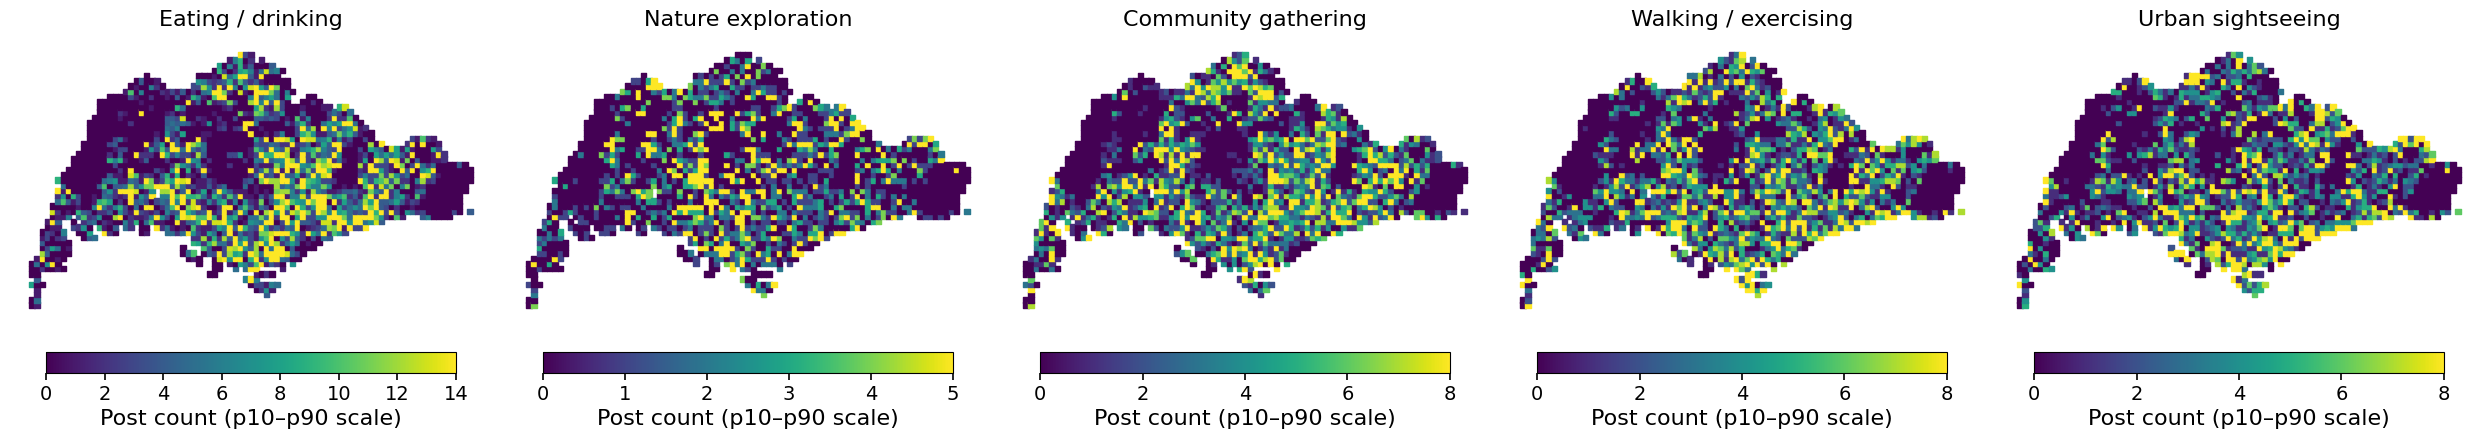

In [17]:
# Activity intensity maps — one row, five activities
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

ACT_COLS = ['eating', 'nature', 'community', 'walking', 'sightseeing']
ACT_LABELS = {
    'eating': 'Eating / drinking',
    'nature': 'Nature exploration',
    'community': 'Community gathering',
    'walking': 'Walking / exercising',
    'sightseeing': 'Urban sightseeing',
}
CBAR_LABEL_SIZE = 16
CBAR_TICK_SIZE = 14

fig, axes = plt.subplots(1, len(ACT_COLS), figsize=(25, 6.5))

for ax, col in zip(axes, ACT_COLS):
    if col not in gdf.columns:
        raise KeyError(f"gdf missing column {col!r}; run the aggregation cell above first.")
    vmin = float(gdf[col].quantile(0.10))
    vmax = float(gdf[col].quantile(0.90))
    norm = Normalize(vmin=vmin, vmax=vmax)
    gdf.plot(
        column=col,
        ax=ax,
        cmap='viridis',
        norm=norm,
        legend=False,
        markersize=15,
        marker='s',
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    )
    sm = cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation='horizontal',
        shrink=0.85,
        pad=0.06,
        fraction=0.05,
    )
    cbar.set_label('Post count (p10–p90 scale)', fontsize=CBAR_LABEL_SIZE)
    cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE, width=1.2, length=5)
    ax.set_title(ACT_LABELS[col], fontsize=16, pad=12)
    ax.set_axis_off()

plt.tight_layout()
fig.savefig('figure/code_0_activity_intensity.png', dpi=300, bbox_inches='tight')
plt.show()


<a id="sec-4-caption"></a>

## 4. Caption analytics for comfort level evaluation

Score each caption by cosine similarity to pre-set comfort / discomfort anchor sentences (four spatial dimensions: SP, FC, AC, CD), then link scores to activity types and aggregate to grid level.

**Inputs:**
- `dataset_post_st_caption_features.npy` — Sentence Transformer (`all-MiniLM-L6-v2`) caption embeddings
- `dataset_post_caption_has_text.npy` — boolean mask for non-empty captions
- `code_0_embedding_index_grid_cluster.csv`, `code_0_cluster_activity_config.json` (from §2–§3)

**Outputs:**
- `dataset_post_comfort_*.npy` — per-post comfort scores (§4.1)
- `dataset_post_caption_activity.npy` — per-post activity label (§4.2)
- `caption_analytics_results.csv` — export table (§4.3)
- Updated `data_grid_point_coordinates.csv`, `data_social_activity.gpkg` with `avg_comfort_*` (§4.4)

**Subsections:**
- [4.1 Comfort scores from caption embeddings](#sec-4-1-comfort)
- [4.2 Integrate comfort with activity types](#sec-4-2-integrate)
- [4.3 Score summary and visualisation](#sec-4-3-summary)
- [4.4 Merge comfort into grid and GPKG](#sec-4-4-merge)


In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd

P = Path('data_post_embedding')


<a id="sec-4-1-comfort"></a>

### 4.1 Comfort scores from caption embeddings

Load caption embeddings and `has_text` mask; encode anchor sentences with `all-MiniLM-L6-v2`; compute raw and min–max normalised comfort scores. Writes `dataset_post_comfort_*.npy`.


In [27]:
# 4.1 Comfort: only .npy inputs (no caption CSV)
from sentence_transformers import SentenceTransformer

cap_emb = np.load(P / 'dataset_post_st_caption_features.npy').astype(np.float32)
has_text_np = np.load(P / 'dataset_post_caption_has_text.npy').astype(bool)
n = len(has_text_np)
if cap_emb.shape[0] != n:
    raise ValueError(f'cap_emb rows {cap_emb.shape[0]} != has_text {n}')

model = SentenceTransformer('all-MiniLM-L6-v2')

comfort_anchors = [
    "A pleasant, clean, safe, and visually appealing street environment with greenery, good lighting, and an inviting atmosphere.",
    "A functional urban place where services, amenities, and everyday activities are convenient and well supported.",
    "A highly accessible place with walkable streets, smooth movement, barrier-free design, convenient access to public transport such as buses and metro, and strong connectivity to surrounding destinations within the urban network.",
    "A socially comfortable environment with lively public interaction and an active atmosphere, but without overcrowding or excessive social pressure.",
]
discomfort_anchors = [
    "An unpleasant, dirty, unsafe, and visually stressful street environment with poor lighting and an uninviting atmosphere.",
    "A dysfunctional urban place where services, amenities, and everyday activities are inconvenient or poorly supported.",
    "A poorly accessible place with difficult walking conditions, physical barriers, inconvenient movement, limited access to public transport such as buses and metro, and weak connectivity to surrounding destinations within the urban network.",
    "A socially uncomfortable environment that feels either overcrowded, chaotic, and oppressive, or isolated, inactive, and lacking meaningful public interaction.",
]

comfort_emb = model.encode(comfort_anchors, normalize_embeddings=True)
discomfort_emb = model.encode(discomfort_anchors, normalize_embeddings=True)

idx = np.flatnonzero(has_text_np)
avg_c = np.full(n, np.nan, dtype=np.float32)
avg_d = np.full(n, np.nan, dtype=np.float32)
raw = np.full(n, np.nan, dtype=np.float32)

if len(idx) > 0:
    sim_c = cap_emb[idx] @ comfort_emb.T
    sim_d = cap_emb[idx] @ discomfort_emb.T
    avg_c[idx] = sim_c.mean(axis=1).astype(np.float32)
    avg_d[idx] = sim_d.mean(axis=1).astype(np.float32)
    raw[idx] = avg_c[idx] - avg_d[idx]

finite = np.isfinite(raw)
score = np.full(n, np.nan, dtype=np.float32)
if finite.any():
    lo, hi = float(raw[finite].min()), float(raw[finite].max())
    if hi > lo:
        score[finite] = ((raw[finite] - lo) / (hi - lo)).astype(np.float32)
    else:
        score[finite] = 0.5

np.save(P / 'dataset_post_comfort_anchor_sim_mean.npy', avg_c)
np.save(P / 'dataset_post_discomfort_anchor_sim_mean.npy', avg_d)
np.save(P / 'dataset_post_comfort_raw_score.npy', raw.astype(np.float32))
np.save(P / 'dataset_post_comfort_score.npy', score)
print('Saved comfort *.npy under', P.resolve())


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved comfort *.npy under /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding


<a id="sec-4-2-integrate"></a>

### 4.2 Integrate comfort with activity types

Rebuild comfort columns from disk; attach `cluster` and `activity` via cluster CSV + activity config (same rules as §3). Writes `dataset_post_caption_activity.npy` (empty string = no mapped activity).


In [2]:
# §4.2 — build df_captions from disk + activity (cluster → activity via code_0_cluster_activity_config.json)
import json
import numpy as np
import pandas as pd
from pathlib import Path

P = Path('data_post_embedding')

has_text = np.load(P / 'dataset_post_caption_has_text.npy').astype(bool)
avg_c = np.load(P / 'dataset_post_comfort_anchor_sim_mean.npy').astype(np.float32)
avg_d = np.load(P / 'dataset_post_discomfort_anchor_sim_mean.npy').astype(np.float32)
raw = np.load(P / 'dataset_post_comfort_raw_score.npy').astype(np.float32)
score = np.load(P / 'dataset_post_comfort_score.npy').astype(np.float32)

gid_path = P / 'dataset_post_embedding_grid_id.npy'
if gid_path.exists():
    gid = np.load(gid_path).astype(np.int64).reshape(-1)
else:
    gid = np.full(len(has_text), -1, dtype=np.int64)

n = min(len(has_text), len(avg_c), len(avg_d), len(raw), len(score), len(gid))

map_csv = P / 'code_0_embedding_index_grid_cluster.csv'
if not map_csv.exists():
    raise FileNotFoundError(map_csv)
map_df = pd.read_csv(map_csv)
if 'embedding_index' in map_df.columns:
    map_df = map_df.sort_values('embedding_index').drop_duplicates('embedding_index', keep='first').reset_index(drop=True)
cfg_path = P / 'code_0_cluster_activity_config.json'
if not cfg_path.exists():
    raise FileNotFoundError(f'Missing {cfg_path}. Place code_0_cluster_activity_config.json under {P.resolve()}.')
cfg = json.loads(cfg_path.read_text(encoding='utf-8'))
drop = set(int(x) for x in cfg.get('drop_clusters', []))
raw_map = cfg.get('cluster_to_activity', {})
cluster_to_activity = {}
for k, v in raw_map.items():
    if v is None or str(v).lower() in ('null', 'none', ''):
        continue
    cluster_to_activity[int(k)] = str(v).strip().lower()

ACT = ['eating', 'nature', 'community', 'walking', 'sightseeing']
for a in cluster_to_activity.values():
    if a not in ACT:
        raise ValueError(f'Unknown activity {a!r} in code_0_cluster_activity_config.json; use one of {ACT}')

if len(map_df) < n:
    raise ValueError(f'{map_csv} rows {len(map_df)} < caption rows {n}')
map_df = map_df.iloc[:n].reset_index(drop=True)
clusters = map_df['cluster'].astype(np.int64).values
activity = []
for i in range(n):
    c = int(clusters[i])
    if c in drop:
        activity.append(None)
    else:
        activity.append(cluster_to_activity.get(c))

df_captions = pd.DataFrame({
    'embedding_index': np.arange(n, dtype=np.int64),
    'grid_id': gid[:n],
    'cluster': clusters,
    'activity': activity,
    'has_text': has_text[:n],
    'comfort_anchor_similarity': avg_c[:n],
    'discomfort_anchor_similarity': avg_d[:n],
    'comfort_raw_score': raw[:n],
    'comfort_score': score[:n],
})

act_np = np.array([x if x is not None else '' for x in activity], dtype=object)
np.save(P / 'dataset_post_caption_activity.npy', act_np)

print(df_captions.shape)
print('activity (non-null):')
print(df_captions['activity'].value_counts(dropna=True))
df_captions.head()


(44228, 9)
activity (non-null):
activity
eating         10326
walking         6473
community       6459
sightseeing     6201
nature          3777
Name: count, dtype: int64


,embedding_index,grid_id,cluster,activity,has_text,comfort_anchor_similarity,discomfort_anchor_similarity,comfort_raw_score,comfort_score
0,0,2,2,walking,True,0.030963,0.035113,-0.004150,0.513033
1,1,2,1,NaN,True,0.101564,0.125953,-0.024389,0.454412
2,2,2,6,eating,True,0.057414,0.062779,-0.005365,0.509514
3,3,2,7,sightseeing,True,0.240415,0.252698,-0.012283,0.489476
4,4,2,5,community,False,NaN,NaN,NaN,NaN


<a id="sec-4-3-summary"></a>

### 4.3 Score summary and visualisation

Summarise and plot comfort scores for rows with `has_text` only (histograms, pie chart). Exports `caption_analytics_results.csv`.


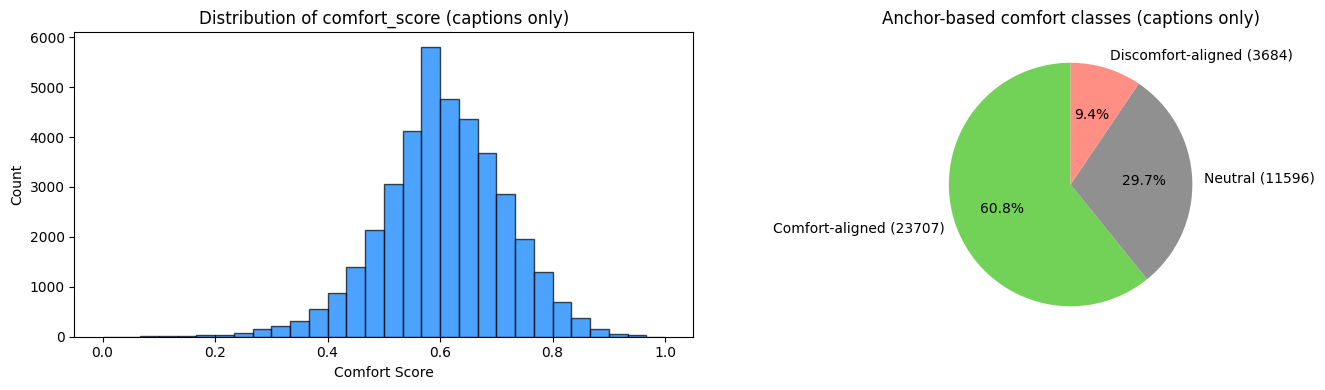

In [8]:
import matplotlib.pyplot as plt

# Plots (text rows only)
sub = df_captions.loc[df_captions['has_text']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sub['comfort_score'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='#007BFF')
axes[0].set_xlabel('Comfort Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of comfort_score (captions only)')

comfort_aligned = (sub['comfort_raw_score'] > 0.02).sum()
neutral = ((sub['comfort_raw_score'] >= -0.02) & (sub['comfort_raw_score'] <= 0.02)).sum()
discomfort_aligned = (sub['comfort_raw_score'] < -0.02).sum()
sizes = [comfort_aligned, neutral, discomfort_aligned]
labels = [f'Comfort-aligned ({comfort_aligned})', f'Neutral ({neutral})', f'Discomfort-aligned ({discomfort_aligned})']
colors = ['#72D257', '#909090', '#FF8E84']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Anchor-based comfort classes (captions only)')

plt.tight_layout()
fig.savefig('figure/code_0_comfort_score_summary.png', dpi=300, bbox_inches='tight')
plt.show()


In [30]:
# Export without any comment text (numeric flags only)
sub = df_captions.loc[df_captions['has_text']]
print('=== Comfort score (rows with text) ===')
print(f"Total embedding rows: {len(df_captions)}")
print(f"Rows with caption encoded: {len(sub)}")
if len(sub):
    print(f"comfort_score mean: {sub['comfort_score'].mean():.4f}")
    print(sub['comfort_score'].describe())

out_csv = P / 'caption_analytics_results.csv'
df_captions.to_csv(out_csv, index=False, encoding='utf-8-sig')
print('Saved (no raw captions):', out_csv.resolve())


=== Comfort score (rows with text) ===
Total embedding rows: 44228
Rows with caption encoded: 38987
comfort_score mean: 0.6063
count    38987.000000
mean         0.606277
std          0.108758
min          0.000000
25%          0.541437
50%          0.604987
75%          0.677597
max          1.000000
Name: comfort_score, dtype: float64
Saved (no raw captions): /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/caption_analytics_results.csv


<a id="sec-4-4-merge"></a>

### 4.4 Merge comfort into grid and GPKG

Compute overall mean `avg_comfort_score` and per-activity means (`avg_comfort_eating`, …, `avg_comfort_sightseeing`) per grid `id` (rows with `has_text` and mapped activity). Updates `data_grid_point_coordinates.csv` and `data_social_activity.gpkg`.


In [33]:
# Mean comfort per grid: overall + per activity → data_grid_point_coordinates.csv
ACT = ['eating', 'nature', 'community', 'walking', 'sightseeing']

points_path = P / 'data_grid_point_coordinates.csv'
if not points_path.exists():
    raise FileNotFoundError(points_path)

pts = pd.read_csv(points_path)
drop_legacy = [c for c in pts.columns if c.startswith('avg_comfort_')]
if drop_legacy:
    pts = pts.drop(columns=drop_legacy)

scored = df_captions[(df_captions['grid_id'] >= 0) & df_captions['has_text']].copy()

location_avg = (
    scored.groupby('grid_id', as_index=False)['comfort_score']
    .mean()
    .rename(columns={'grid_id': 'id', 'comfort_score': 'avg_comfort_score'})
)

sub_act = scored[scored['activity'].notna()].copy()

pts['id'] = pd.to_numeric(pts['id'], errors='coerce')
location_avg['id'] = pd.to_numeric(location_avg['id'], errors='coerce')

pts = pts.merge(location_avg, on='id', how='left')

if len(sub_act) > 0:
    cat_avg = (
        sub_act.groupby(['grid_id', 'activity'])['comfort_score']
        .mean()
        .unstack('activity')
    )
    for a in ACT:
        if a not in cat_avg.columns:
            cat_avg[a] = np.nan
    cat_avg = cat_avg[ACT]
    cat_avg = cat_avg.add_prefix('avg_comfort_').reset_index().rename(columns={'grid_id': 'id'})
    cat_avg['id'] = pd.to_numeric(cat_avg['id'], errors='coerce')
    pts = pts.merge(cat_avg, on='id', how='left')
else:
    for a in ACT:
        pts[f'avg_comfort_{a}'] = 0.0

score_cols = ['avg_comfort_score'] + [f'avg_comfort_{a}' for a in ACT]
for col in score_cols:
    if col in pts.columns:
        pts[col] = pts[col].fillna(0)

pts.to_csv(points_path, index=False, encoding='utf-8-sig')
print('Updated CSV:', points_path.resolve())

output_gpkg = P / 'data_social_activity.gpkg'
gdf_comfort = gpd.GeoDataFrame(pts, geometry=gpd.points_from_xy(pts.longitude, pts.latitude))
gdf_comfort.to_file(output_gpkg, driver='GPKG')
print('Saved GPKG:', output_gpkg.resolve())

show_cols = ['id', 'avg_comfort_score'] + [f'avg_comfort_{a}' for a in ACT if f'avg_comfort_{a}' in pts.columns]
print(pts[show_cols].head())


Updated CSV: /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/data_grid_point_coordinates.csv
Saved GPKG: /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/data_social_activity.gpkg
   id  avg_comfort_score  avg_comfort_eating  avg_comfort_nature  \
0   0           0.000000            0.000000            0.000000   
1   1           0.000000            0.000000            0.000000   
2   2           0.559116            0.561076            0.357431   
3   3           0.540892            0.000000            0.000000   
4   4           0.000000            0.000000            0.000000   

   avg_comfort_community  avg_comfort_walking  avg_comfort_sightseeing  
0                0.00000             0.000000                 0.000000  
1                0.00000             0.000000                 0.000000  
2                0.46878             0.535751                 0.565555  
3                0.00000             0.548579               

/Users/sijieyang/anaconda3/lib/python3.11/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


<a id="sec-5-result-viz"></a>

## 5. Result visualisation

Merge activity intensity and category comfort; compute **social activity comfort** = activity intensity × category comfort; refresh GPKG and plot three-panel maps per activity.

**Inputs:**
- `data_social_activity.gpkg` — activity columns from §3, `avg_comfort_*` from §4.4
- `data_grid_point_coordinates.csv`

**Outputs:**
- Updated `data_social_activity.gpkg` with `social_activity_comfort_*` columns
- Activity | comfort | product maps (§5.1)

**Prerequisites:** Run §3 and §4.4 first. Override `gpkg_path` / `points_csv_path` in code if needed.

**Subsections:**
- [5.1 Maps (3 panels per activity)](#sec-5-1-maps)


In [1]:
import pandas as pd
import geopandas as gpd
import fiona
from pathlib import Path

P = Path('data_post_embedding')

In [2]:
# Input paths (same pipeline as §3–§4)
gpkg_path = P / 'data_social_activity.gpkg'
points_csv_path = P / 'data_grid_point_coordinates.csv'

if not gpkg_path.exists():
    raise FileNotFoundError(f'GeoPackage not found: {gpkg_path}')
if not points_csv_path.exists():
    raise FileNotFoundError(f'CSV not found: {points_csv_path}')

layers = fiona.listlayers(str(gpkg_path))
print("Available layers:", layers)

Available layers: ['data_social_activity']


In [3]:
layer_name = layers[0]
gdf = gpd.read_file(gpkg_path, layer=layer_name)
points_df = pd.read_csv(points_csv_path)

print("GPKG rows:", len(gdf))
print("CSV rows:", len(points_df))
print("GPKG columns:", list(gdf.columns))
print("CSV columns:", list(points_df.columns))

GPKG rows: 2096
CSV rows: 2096
GPKG columns: ['id', 'longitude', 'latitude', 'eating', 'nature', 'community', 'walking', 'sightseeing', 'avg_comfort_score', 'avg_comfort_eating', 'avg_comfort_nature', 'avg_comfort_community', 'avg_comfort_walking', 'avg_comfort_sightseeing', 'geometry']
CSV columns: ['id', 'longitude', 'latitude', 'eating', 'nature', 'community', 'walking', 'sightseeing', 'avg_comfort_score', 'avg_comfort_eating', 'avg_comfort_nature', 'avg_comfort_community', 'avg_comfort_walking', 'avg_comfort_sightseeing']


In [4]:
# Ensure both sides use numeric id for alignment
if 'id' not in gdf.columns:
    raise KeyError("Column 'id' not found in GeoPackage layer. Please check gdf.columns and update the join key.")
if 'id' not in points_df.columns:
    raise KeyError("Column 'id' not found in data_grid_point_coordinates.csv.")

# Collect all score columns from points file
score_cols = [c for c in points_df.columns if c.startswith('avg_comfort_')]
if len(score_cols) == 0:
    raise KeyError("No comfort columns found in data_grid_point_coordinates.csv (expected columns starting with 'avg_comfort_').")

gdf['id'] = pd.to_numeric(gdf['id'], errors='coerce')
points_df['id'] = pd.to_numeric(points_df['id'], errors='coerce')

# Prefer CSV comfort columns over any stale copies already in the GPKG
drop_from_gpkg = [c for c in score_cols if c in gdf.columns]
if drop_from_gpkg:
    gdf = gdf.drop(columns=drop_from_gpkg)

score_df = points_df[['id'] + score_cols].drop_duplicates(subset=['id'])
gdf_merged = gdf.merge(score_df, on='id', how='left')

category_pairs = [
    ("eating", "avg_comfort_eating", "social_activity_comfort_eating"),
    ("nature", "avg_comfort_nature", "social_activity_comfort_nature"),
    ("community", "avg_comfort_community", "social_activity_comfort_community"),
    ("walking", "avg_comfort_walking", "social_activity_comfort_walking"),
    ("sightseeing", "avg_comfort_sightseeing", "social_activity_comfort_sightseeing"),
]

# If activity > 0 but the matching category comfort is 0, replace comfort with that column's mean
activity_comfort_impute = {}
for activity_col, score_col, _ in category_pairs:
    if activity_col not in gdf_merged.columns or score_col not in gdf_merged.columns:
        continue
    mask = (gdf_merged[activity_col].fillna(0) > 0) & (gdf_merged[score_col].fillna(0) == 0)
    ref = gdf_merged.loc[~mask, score_col].mean()
    if pd.isna(ref):
        ref = gdf_merged[score_col].mean()
    if pd.isna(ref):
        ref = 0.0
    n = int(mask.sum())
    activity_comfort_impute[score_col] = {"reference_mean": ref, "rows_imputed": n}
    if n > 0:
        gdf_merged.loc[mask, score_col] = ref
print(
    "Imputed category comfort where activity>0 and comfort==0 (using column mean):",
    activity_comfort_impute,
)

# Create new columns: social activity comfort = activity_intensity * avg_comfort_category
for activity_col, score_col, out_col in category_pairs:
    if activity_col in gdf_merged.columns and score_col in gdf_merged.columns:
        gdf_merged[out_col] = gdf_merged[activity_col].fillna(0) * gdf_merged[score_col].fillna(0)
    else:
        gdf_merged[out_col] = 0

new_cols = [x[2] for x in category_pairs]

activity_cols = [a for a, _, _ in category_pairs]
if 'avg_comfort_score' in gdf_merged.columns:
    n_zero_overall_comfort_but_activity = (
        (gdf_merged['avg_comfort_score'].fillna(0) == 0)
        & (gdf_merged[activity_cols].fillna(0).sum(axis=1) > 0)
    ).sum()
    print(
        "IDs with avg_comfort_score == 0 but sum(activity categories) > 0:",
        int(n_zero_overall_comfort_but_activity),
    )
for activity_col, score_col, _ in category_pairs:
    if activity_col not in gdf_merged.columns or score_col not in gdf_merged.columns:
        continue
    n_mismatch = (
        (gdf_merged[score_col].fillna(0) == 0)
        & (gdf_merged[activity_col].fillna(0) > 0)
    ).sum()
    print(
        f"IDs with {score_col} == 0 but {activity_col} > 0:",
        int(n_mismatch),
    )

print(gdf_merged[['id'] + score_cols + new_cols].head())
print("Merged score columns:", score_cols)
print("New social activity comfort columns:", new_cols)
print("Rows with all scores = 0:", (gdf_merged[score_cols].sum(axis=1) == 0).sum())

Imputed category comfort where activity>0 and comfort==0 (using column mean): {'avg_comfort_eating': {'reference_mean': np.float64(0.39007054956017395), 'rows_imputed': 27}, 'avg_comfort_nature': {'reference_mean': np.float64(0.2885632237865497), 'rows_imputed': 44}, 'avg_comfort_community': {'reference_mean': np.float64(0.3727075765242719), 'rows_imputed': 36}, 'avg_comfort_walking': {'reference_mean': np.float64(0.3758624917983519), 'rows_imputed': 33}, 'avg_comfort_sightseeing': {'reference_mean': np.float64(0.3594262064015709), 'rows_imputed': 59}}
IDs with avg_comfort_score == 0 but sum(activity categories) > 0: 15
IDs with avg_comfort_eating == 0 but eating > 0: 0
IDs with avg_comfort_nature == 0 but nature > 0: 0
IDs with avg_comfort_community == 0 but community > 0: 0
IDs with avg_comfort_walking == 0 but walking > 0: 0
IDs with avg_comfort_sightseeing == 0 but sightseeing > 0: 0
   id  avg_comfort_score  avg_comfort_eating  avg_comfort_nature  \
0   0           0.000000       

In [5]:
output_gpkg_path = P / 'data_social_activity.gpkg'

gdf_merged.to_file(output_gpkg_path, driver='GPKG', mode='w')

print("Saved merged GeoPackage:", output_gpkg_path.resolve())
print("All columns:")
print(list(gdf_merged.columns))

Saved merged GeoPackage: /Users/sijieyang/Documents/Urban-Comfort-Potential/data_post_embedding/data_social_activity.gpkg
All columns:
['id', 'longitude', 'latitude', 'eating', 'nature', 'community', 'walking', 'sightseeing', 'geometry', 'avg_comfort_score', 'avg_comfort_eating', 'avg_comfort_nature', 'avg_comfort_community', 'avg_comfort_walking', 'avg_comfort_sightseeing', 'social_activity_comfort_eating', 'social_activity_comfort_nature', 'social_activity_comfort_community', 'social_activity_comfort_walking', 'social_activity_comfort_sightseeing']


/Users/sijieyang/anaconda3/lib/python3.11/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


<a id="sec-5-1-maps"></a>

### 5.1 Maps (3 panels per activity)

Each row: **left** — activity intensity; **middle** — `avg_comfort_*`; **right** — `social_activity_comfort_*` (intensity × comfort). Saves `figure/code_0_social_activity_comfort_maps.png`.


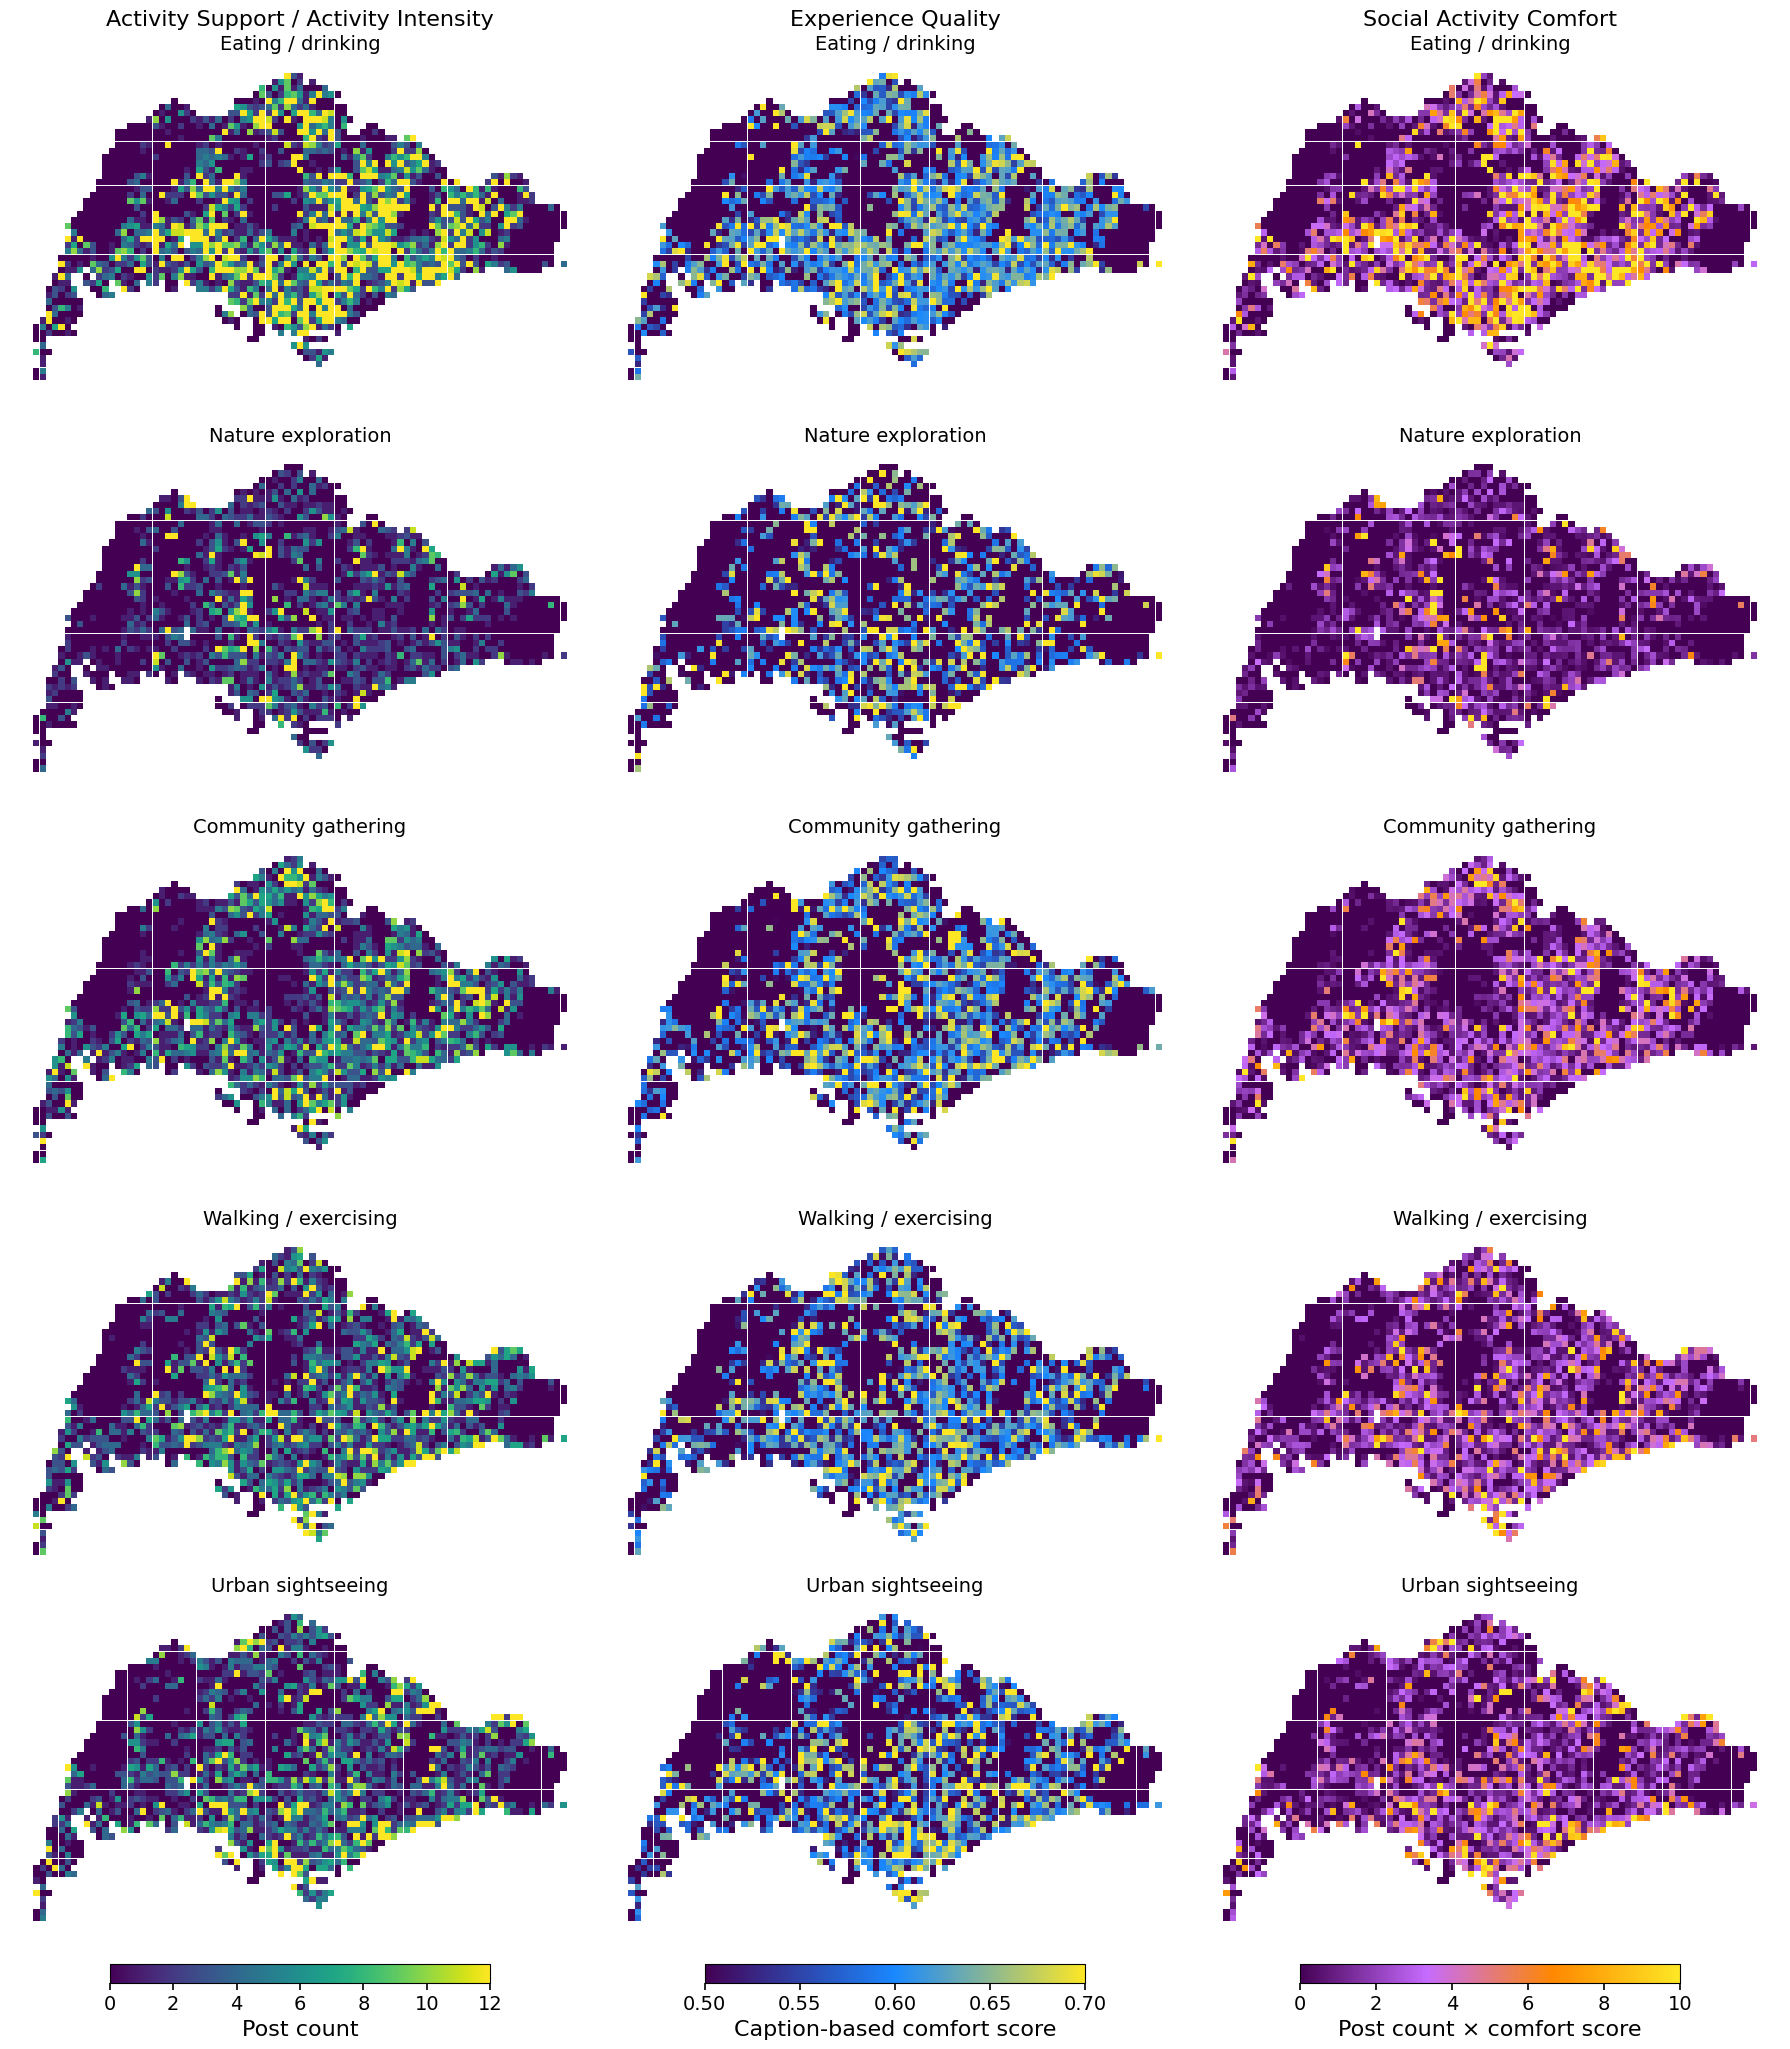

In [23]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, LinearSegmentedColormap

PAPER_COLORS = {
    "teal": "#2279B5",
    "yellow": "#FDE725",
    "purple_dark": "#440154",
    "purple_light": "#C66BFF",
    "orange": "#FF8800",
    "blue": "#1988FF",
}

# Col 2: experience quality — dark purple → blue (mid) → yellow
CMAP_EXPERIENCE = LinearSegmentedColormap.from_list(
    "paper_experience",
    [
        PAPER_COLORS["purple_dark"],
        PAPER_COLORS["blue"],
        PAPER_COLORS["yellow"],
    ],
)
# Col 3: social activity comfort — dark purple → lavender → orange → yellow
CMAP_SAC = LinearSegmentedColormap.from_list(
    "paper_sac",
    [
        PAPER_COLORS["purple_dark"],
        PAPER_COLORS["purple_light"],
        PAPER_COLORS["orange"],
        PAPER_COLORS["yellow"],
    ],
)

category_pairs = [
    ("eating", "avg_comfort_eating", "social_activity_comfort_eating"),
    ("nature", "avg_comfort_nature", "social_activity_comfort_nature"),
    ("community", "avg_comfort_community", "social_activity_comfort_community"),
    ("walking", "avg_comfort_walking", "social_activity_comfort_walking"),
    ("sightseeing", "avg_comfort_sightseeing", "social_activity_comfort_sightseeing"),
]

ACT_LABELS = {
    "eating": "Eating / drinking",
    "nature": "Nature exploration",
    "community": "Community gathering",
    "walking": "Walking / exercising",
    "sightseeing": "Urban sightseeing",
}

COLUMN_TITLES = [
    "Activity Support / Activity Intensity",
    "Experience Quality",
    "Social Activity Comfort",
]
COLUMN_CBAR_LABELS = [
    "Post count",
    "Caption-based comfort score",
    "Post count × comfort score",
]
COLUMN_CMAPS = ["viridis", CMAP_EXPERIENCE, CMAP_SAC]
COLUMN_VRANGE = [(0, 12), (0.5, 0.7), (0, 10)]
CBAR_LABEL_SIZE = 16
CBAR_TICK_SIZE = 14

n_rows = len(category_pairs)
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4.2 * n_rows))

if n_rows == 1:
    axes = [axes]

for i, (cat_col, score_col, comfort_col) in enumerate(category_pairs):
    cols = [cat_col, score_col, comfort_col]
    show_legend = i == n_rows - 1

    for j, (col, cmap, (vmin, vmax)) in enumerate(zip(cols, COLUMN_CMAPS, COLUMN_VRANGE)):
        ax = axes[i][j]

        if col not in gdf_merged.columns:
            ax.text(0.5, 0.5, f"Missing column: {col}", ha="center", va="center")
            ax.set_axis_off()
            continue

        norm = Normalize(vmin=vmin, vmax=vmax)
        gdf_merged.plot(
            column=col,
            cmap=cmap,
            norm=norm,
            linewidth=0,
            legend=False,
            ax=ax,
            markersize=20,
            marker="s",
            missing_kwds={"color": "lightgrey"},
        )

        ax.set_title(ACT_LABELS[cat_col], fontsize=14, pad=8)
        ax.set_axis_off()

        if show_legend:
            sm = cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(
                sm,
                ax=ax,
                orientation="horizontal",
                shrink=0.9,
                pad=0.08,
                fraction=0.05,
            )
            cbar.set_label(COLUMN_CBAR_LABELS[j], fontsize=CBAR_LABEL_SIZE)
            cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE, width=1.2, length=5)

plt.tight_layout(rect=[0, 0, 1, 0.97])
for j, title in enumerate(COLUMN_TITLES):
    pos = axes[0, j].get_position()
    fig.text(
        pos.x0 + pos.width / 2,
        pos.y1 + 0.015,
        title,
        ha="center",
        va="bottom",
        fontsize=16,
    )

fig.savefig('figure/code_0_social_activity_comfort_maps.png', dpi=300, bbox_inches='tight')
plt.show()
